# 2.1

In [86]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

data = sio.loadmat('HW08_Problem2.mat')


print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'q_samples', 'variance0_samps'])


In [87]:
q, s2 = data['q_samples'], data['variance0_samps']
qbar = np.mean(q, axis = 1)
print("Mean q, q_bar = ", qbar)
s2bar = np.mean(s2)
print("Mean variance, s2bar = ", s2bar)

Mean q, q_bar =  [-1.73572551e+01  1.81973276e-03]
Mean variance, s2bar =  0.04200534049451376


# 2.2

In [88]:
import os, sys
sys.path.append('../hw1/')
import heat_rod as hr

x_target = 10.0  # cm

## ASSUMING ALL VALUES AS IN HW08 problem 3
a = 0.95  # cm
b = 0.95  # cm
k = 2.3  # W/cm·C
Tamb = 21.29  # C
L = 70
# Create the rod model
rod = hr.SteadyStateRod(a, b, None, k, None, Tamb, L)

# Evaluate Ts at x=10 for each MCMC sample
Ts_samples = np.zeros(len(q.T))

for i, (Phi, h) in enumerate(q.T):
    Ts_samples[i] = rod.Ts(x_target, h=h, k=k, Phi=Phi, Tamb=Tamb)

# Calculate empirical mean and variance
Ts_mean = np.mean(Ts_samples)
Ts_variance = np.var(Ts_samples)

print("\nProblem 2.2:")
print(f"At x = {x_target} cm:")
print(f"Empirical mean of Ts: {Ts_mean:.6f} °C")
print(f"Empirical variance of Ts: {Ts_variance:.6f}")



Problem 2.2:
At x = 10.0 cm:
Empirical mean of Ts: 94.790544 °C
Empirical variance of Ts: 0.383737


# 2.3 

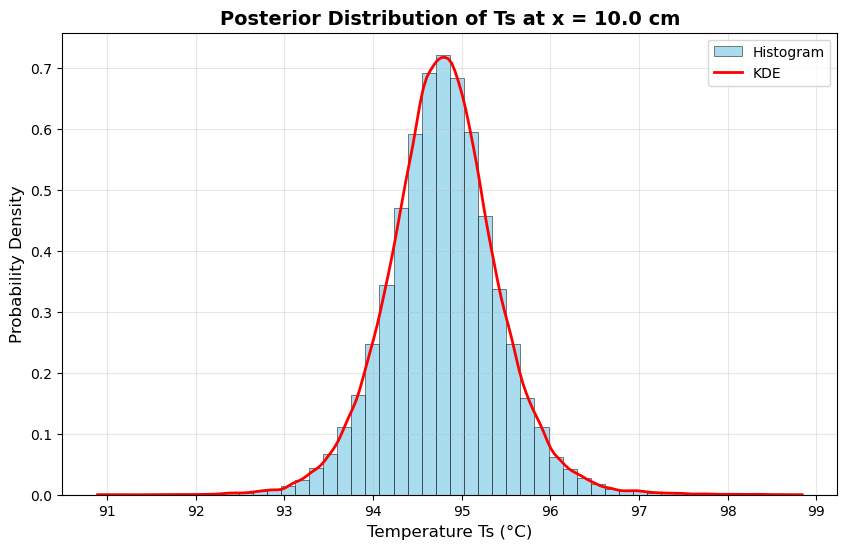

In [89]:
from scipy import stats
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram
n_bins = 50  
counts, bins, patches = ax.hist(Ts_samples, bins=n_bins, density=True, 
                                 alpha=0.7, color='skyblue', 
                                 edgecolor='black', linewidth=0.5,
                                 label='Histogram')

kde = stats.gaussian_kde(Ts_samples)
x_range = np.linspace(Ts_samples.min(), Ts_samples.max(), 200)
kde_values = kde(x_range)
ax.plot(x_range, kde_values, 'r-', linewidth=2, label='KDE')


ax.set_xlabel('Temperature Ts (°C)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Posterior Distribution of Ts at x = {x_target} cm', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)


# 2.4



Problem 2.4:

Manual calculation (order statistics):
Total samples: 100000
Lower bound (index 2500): 93.5703 °C
Upper bound (index 97499): 96.0452 °C

Verification:
Samples within interval: 95001 out of 100000 (95.00%)


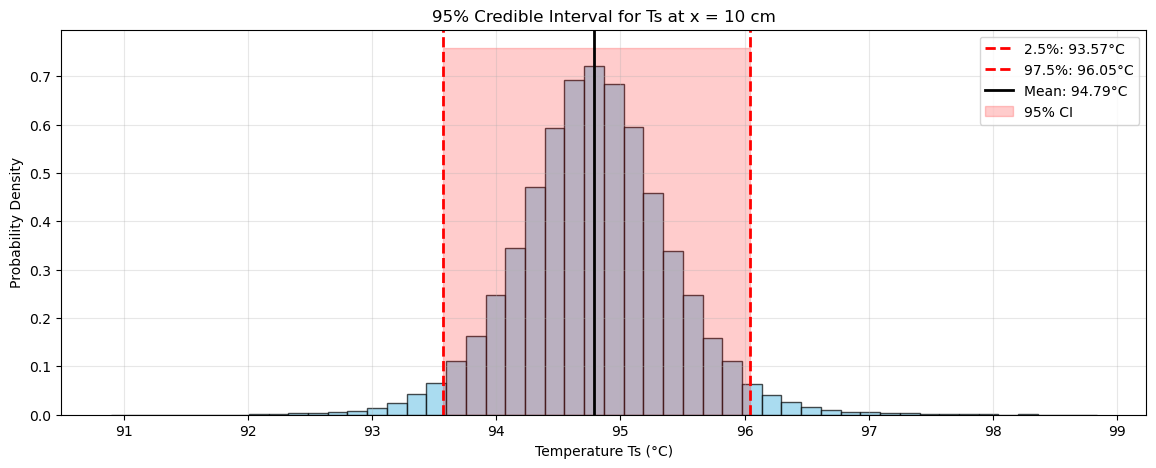

In [90]:
print("\nProblem 2.4:")
def ci(Ts_samples):
    sorted_Ts = np.sort(Ts_samples)
    n_samples = len(sorted_Ts)

    # Find indices for the 2.5th and 97.5th percentiles
    lower_idx = int(np.floor(0.025 * n_samples))  # 2.5% of samples
    upper_idx = int(np.ceil(0.975 * n_samples)) - 1  # 97.5% of samples

    # Get the values at these indices
    lower_bound_manual = sorted_Ts[lower_idx]
    upper_bound_manual = sorted_Ts[upper_idx]

    print(f"\nManual calculation (order statistics):")
    print(f"Total samples: {n_samples}")
    print(f"Lower bound (index {lower_idx}): {lower_bound_manual:.4f} °C")
    print(f"Upper bound (index {upper_idx}): {upper_bound_manual:.4f} °C")

    # Verify that approximately 95% of samples fall within this interval
    within_interval = np.sum((Ts_samples >= lower_bound_manual) & (Ts_samples <= upper_bound_manual))
    percentage_within = (within_interval / n_samples) * 100

    print(f"\nVerification:")
    print(f"Samples within interval: {within_interval} out of {n_samples} ({percentage_within:.2f}%)")

    # Visualize the credible interval
    import matplotlib.pyplot as plt

    fig, (ax1) = plt.subplots(1, 1, figsize=(14, 5))

    # Plot 1: Histogram with credible interval
    ax1.hist(Ts_samples, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    ax1.axvline(lower_bound_manual, color='red', linestyle='--', linewidth=2, label=f'2.5%: {lower_bound_manual:.2f}°C')
    ax1.axvline(upper_bound_manual, color='red', linestyle='--', linewidth=2, label=f'97.5%: {upper_bound_manual:.2f}°C')
    ax1.axvline(np.mean(Ts_samples), color='black', linestyle='-', linewidth=2, label=f'Mean: {np.mean(Ts_samples):.2f}°C')
    ax1.fill_betweenx([0, ax1.get_ylim()[1]], lower_bound_manual, upper_bound_manual, alpha=0.2, color='red', label='95% CI')
    ax1.set_xlabel('Temperature Ts (°C)')
    ax1.set_xlabel('Temperature Ts (°C)')
    ax1.set_ylabel('Probability Density')
    ax1.set_title(f'95% Credible Interval for Ts at x = 10 cm')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
ci(Ts_samples=Ts_samples)

Interval: [93.5703 °C, 96.0452 °C]

# 2.5


Manual calculation (order statistics):
Total samples: 100000
Lower bound (index 2500): 93.4995 °C
Upper bound (index 97499): 96.1185 °C

Verification:
Samples within interval: 95000 out of 100000 (95.00%)


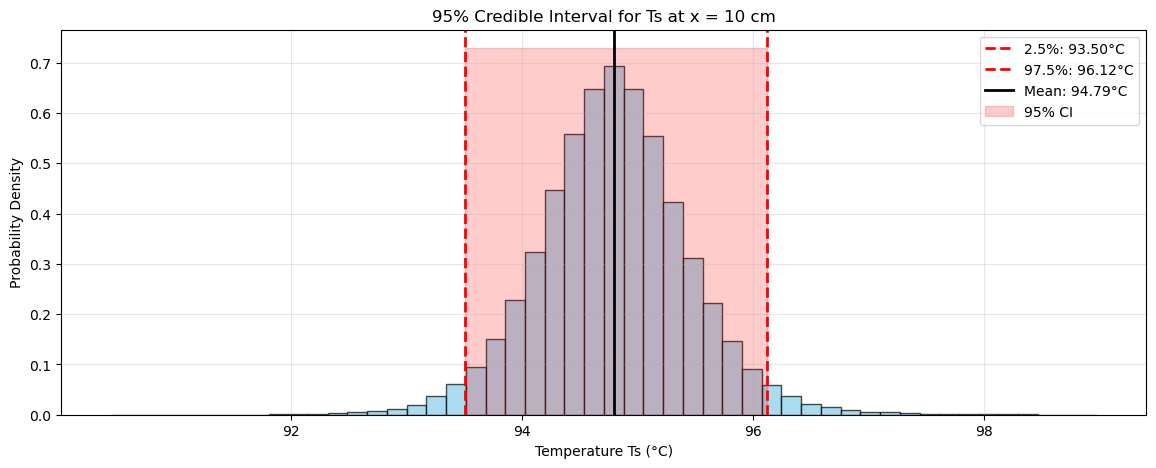

In [91]:
alpha = 0.05  # for 95% prediction interval
def pi(Ts_samples = Ts_samples, s2 = s2):
    n_samples = len(Ts_samples)
    prediction_samples = np.zeros(n_samples)
    np.random.seed(42)  
    s2 = s2.flatten()
    for i in range(n_samples):
        Ts_i = Ts_samples[i]

        sigma2_i = s2[i] #if s2.ndim == 1 else s2[i, 0]
        
        # Generate random error from N(0, sigma2_i)
        # Standard deviation is sqrt(sigma2_i)
        epsilon_i = np.random.normal(0, np.sqrt(sigma2_i))
        # Prediction sample = Ts + error
        prediction_samples[i] = Ts_i + epsilon_i
    return prediction_samples
prediction_samples = pi(Ts_samples)
ci(Ts_samples=prediction_samples)

Interval: [93.4995 °C, 96.1185 °C]. Notice that the prediction interval is larger than the credibility interval.

# 2.6

In [94]:
x = np.array([
    10, 14, 18, 22, 26, 30, 34, 38,
    42, 46, 50, 54, 58, 62, 66
])

y_obs = np.array([
    96.14, 80.12, 67.66, 57.96, 50.90, 44.84, 39.75, 36.16,
    33.31, 31.15, 29.28, 27.88, 27.18, 26.40, 25.86
])

# Number of MCMC samples
n_samples = q.shape[1]

# Initialize arrays to store results for each x location
n_x = len(x)
Ts_mean_all = np.zeros(n_x)
Ts_lower_cred_all = np.zeros(n_x)
Ts_upper_cred_all = np.zeros(n_x)
Ts_lower_pred_all = np.zeros(n_x)
Ts_upper_pred_all = np.zeros(n_x)

# For each x location, compute credibility and prediction intervals
for idx, x_val in enumerate(x):
    print(f"Processing x = {x_val} cm...")
    
    # Evaluate Ts at this x for each MCMC sample
    Ts_samples_x = np.zeros(n_samples)
    for i in range(n_samples):
        Phi = q[0, i]
        h = q[1, i]
        Ts_samples_x[i] = rod.Ts(x_val, h=h, k=k, Phi=Phi, Tamb=Tamb)
    
    # Calculate mean Ts
    Ts_mean_all[idx] = np.mean(Ts_samples_x)
    
    # Calculate 95% credible interval (parameter uncertainty only)
    Ts_lower_cred_all[idx] = np.percentile(Ts_samples_x, 2.5)
    Ts_upper_cred_all[idx] = np.percentile(Ts_samples_x, 97.5)
    
    # Generate prediction samples (including measurement error)
    np.random.seed(42)  # for reproducibility
    prediction_samples_x = np.zeros(n_samples)
    # for i in range(n_samples):
    #     # Add random error based on corresponding variance sample
    #     epsilon_i = np.random.normal(0, np.sqrt(s2[i]))
    #     print(epsilon_i)
    #     prediction_samples_x[i] = Ts_samples_x[i] + epsilon_i
    epsilon = np.random.normal(0, np.sqrt(s2))
    prediction_samples_x = Ts_samples_x + epsilon
    
    # Calculate 95% prediction interval
    Ts_lower_pred_all[idx] = np.percentile(prediction_samples_x, 2.5)
    Ts_upper_pred_all[idx] = np.percentile(prediction_samples_x, 97.5)

# Calculate the difference between observations and predicted values using mean q
# Using mean q (qbar) for deterministic prediction
qbar = np.mean(q, axis=1)
Phi_bar, h_bar = qbar[0], qbar[1]

# Calculate Ts_pred using mean parameters
Ts_pred_mean_params = np.zeros(n_x)
for idx, x_val in enumerate(x):
    Ts_pred_mean_params[idx] = rod.Ts(x_val, h=h_bar, k=k, Phi=Phi_bar, Tamb=Tamb)

# Calculate residuals: y_obs - Ts(x, qbar)
residuals = y_obs - Ts_pred_mean_params


Processing x = 10 cm...
Processing x = 14 cm...
Processing x = 18 cm...
Processing x = 22 cm...
Processing x = 26 cm...
Processing x = 30 cm...
Processing x = 34 cm...
Processing x = 38 cm...
Processing x = 42 cm...
Processing x = 46 cm...
Processing x = 50 cm...
Processing x = 54 cm...
Processing x = 58 cm...
Processing x = 62 cm...
Processing x = 66 cm...


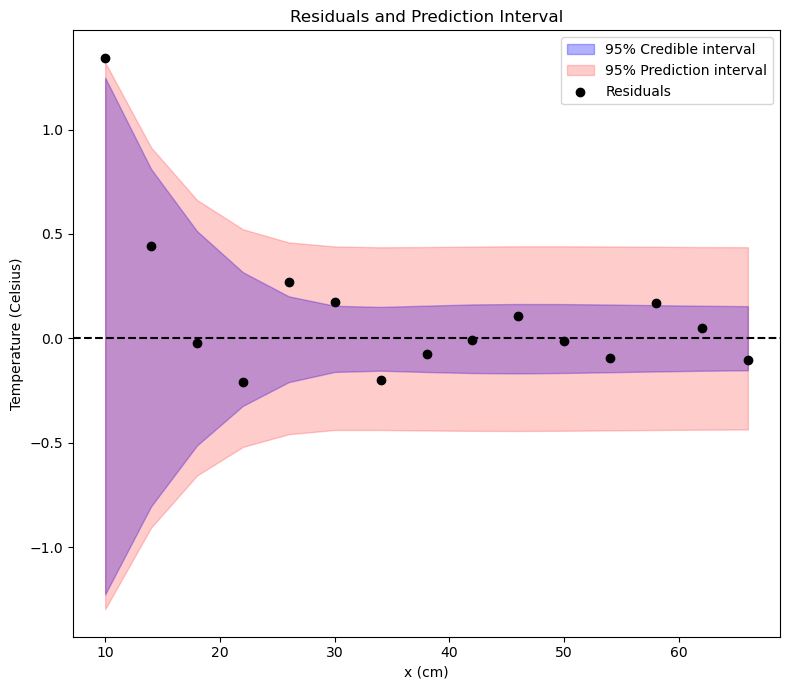

In [99]:
import matplotlib.pyplot as plt

# Create figure
fig, (ax1) = plt.subplots(1, 1, figsize=(8,7), sharex=True)

# -------------------------------------------------
# TOP PANEL: predictions + intervals
# -------------------------------------------------

# Observations
# ax1.scatter(x, y_obs, color='black', label='Observations', marker = "*")

# Mean predicted temperature
# ax1.plot(x, Ts_mean_all, color='blue', label='Mean prediction')

# Credible interval (parameter uncertainty)
ax1.fill_between(
    x,
    Ts_lower_cred_all - Ts_pred_mean_params,
    Ts_upper_cred_all - Ts_pred_mean_params,
    color='blue',
    alpha=0.3,
    label='95% Credible interval'
)

cred_lower_err = Ts_mean_all - Ts_lower_cred_all
cred_upper_err = Ts_upper_cred_all - Ts_mean_all

# ax1.errorbar(
#     x,
#     Ts_mean_all,
#     yerr=[cred_lower_err, cred_upper_err],
#     fmt='none',          # no marker for the mean
#     ecolor='blue',
#     elinewidth=2,
#     capsize=5,
#     label='95% Credible interval'
# )

# Prediction interval (includes measurement noise)
ax1.fill_between(
    x,
    Ts_lower_pred_all - Ts_pred_mean_params,
    Ts_upper_pred_all - Ts_pred_mean_params,
    color='red',
    alpha=0.2,
    label='95% Prediction interval'
)

pred_lower_err = Ts_mean_all - Ts_lower_pred_all
pred_upper_err = Ts_upper_pred_all - Ts_mean_all

# ax1.errorbar(
#     x,
#     Ts_mean_all,
#     yerr=[pred_lower_err, pred_upper_err],
#     fmt='none',
#     ecolor='red',
#     elinewidth=1.5,
#     capsize=4,
#     label='95% Prediction interval'
# )

ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Posterior Predictions with Credible and Prediction Intervals")
ax1.legend()

# -------------------------------------------------
# BOTTOM PANEL: residuals
# -------------------------------------------------

# Residuals
ax1.scatter(x, residuals, color='black', label='Residuals')

# zero reference line
ax1.axhline(0, color='k', linestyle='--')

# Prediction interval centered around zero
lower_centered = Ts_lower_pred_all - Ts_pred_mean_params
upper_centered = Ts_upper_pred_all - Ts_pred_mean_params

# ax1.fill_between(
#     x,
#     lower_centered,
#     upper_centered,
#     color='green',
#     alpha=0.2,
#     label='Prediction interval'
# )

pred_lower_err = Ts_mean_all - Ts_lower_pred_all
pred_upper_err = Ts_upper_pred_all - Ts_mean_all

# ax1.errorbar(
#     x,
#     residuals,
#     yerr=[pred_lower_err, pred_upper_err],
#     fmt='none',
#     ecolor='red',
#     elinewidth=1.5,
#     capsize=4,
#     label='95% Prediction interval'
# )

ax1.set_xlabel("x (cm)")
ax1.set_ylabel(r"Temperature (Celsius)")
ax1.set_title("Residuals and Prediction Interval")
ax1.legend()

plt.tight_layout()
plt.show()

In [100]:
inside = (y_obs >= Ts_lower_pred_all) & (y_obs <= Ts_upper_pred_all)

percent_inside = 100 * np.sum(inside) / len(y_obs)

print(f"Percentage of observations inside prediction interval: {percent_inside:.1f}%")

Percentage of observations inside prediction interval: 93.3%


We expect 95\%  of observations to lie within the prediction intervals. Empirically, we have 93.3\% observations within the prediction intervals, which is nearly equal to the expected/correct percentage of observations within the prediction interval.